## 1.1 linear Regression
- using Robust Scaler

### Importing librarires and pipelines

In [1]:
import sys
sys.path.append(r"e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken")

In [2]:
from src.data_loader import load_data
from src.preprocessing import clean_data
from src.feature_engineering import add_features
from src.pipelines import get_pipeline
from src.evalute import print_scores

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### Loading train and test data sets

In [3]:
train_df = load_data(r"e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken\data\train.csv")
test_df = load_data(r"e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken\data\test.csv")

In [4]:
train_df = clean_data(train_df)
test_df = clean_data(test_df)

train_df = add_features(train_df)
test_df = add_features(test_df)

e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken\src\preprocessing.py:40: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken\src\preprocessing.py:43: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], errors='coerce').dt.strftime('%H:%M:%S')
e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken\src\preprocessing.py:44: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time_Order_picked'] = pd.to_datetime(df['T

Column 'Time_taken(min)' not found in DataFrame!


e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken\src\preprocessing.py:40: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken\src\preprocessing.py:43: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], errors='coerce').dt.strftime('%H:%M:%S')
e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken\src\preprocessing.py:44: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time_Order_picked'] = pd.to_datetime(df['T

### Defining Target feature and other features

In [5]:
target = "Time_taken(min)"

# Drop rows where target is missing
train_df = train_df.dropna(subset=[target])

numeric_features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries",
    "distance_km",
    "order_to_pickup_time",
    "order_hour",
    "is_weekend"
]

categorical_features = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

X = train_df[numeric_features + categorical_features]
y = train_df[target]

### Train-Test split
- test dataset doesn't have the target feature so i will submit the submission file with the predicted target feature

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Building pipeline with linear regression

In [7]:
model = LinearRegression()
pipeline = get_pipeline(model, numeric_features, categorical_features)

### Training the model

In [8]:
pipeline.fit(X_train, y_train)

c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['Festival']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['Delivery_person_Age',
                                                   'Delivery_person_Ratings',
                                                   'multiple_deliveries',
                                                   'distance_km',
                                                   'order_to_pickup_time',
                                                   'order_hour',
                                                   'is_weekend']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Weatherconditions',
                                                   'Road_traffic_density',
                                                   'Type_of_order',
                                                   'Type_of_vehicle',
                                                   'Festival', 'City'])])),
                ('regressor', LinearRegression())])

In [9]:
print_scores(pipeline, X_train, y_train, X_test, y_test)

c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['Festival']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['Festival']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['Festival']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['

Train MAE: 5.161768144457132
Test MAE: 5.146578672654479
Train MSE: 42.93549538892123
Test MSE: 42.969151115595544
Train R2: 0.5129135295342191
Test R2: 0.5099217123134653


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['Festival']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['Festival']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


### To improve Accuracy -> implementing Ridge Regression

In [10]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
ridge_pipeline = get_pipeline(model, numeric_features, categorical_features)

In [11]:
ridge_pipeline.fit(X_train, y_train)

c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['Festival']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['Delivery_person_Age',
                                                   'Delivery_person_Ratings',
                                                   'multiple_deliveries',
                                                   'distance_km',
                                                   'order_to_pickup_time',
                                                   'order_hour',
                                                   'is_weekend']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Weatherconditions',
                                                   'Road_traffic_density',
                                                   'Type_of_order',
                                                   'Type_of_vehicle',
                                                   'Festival', 'City'])])),
                ('regressor', Ridge())])

In [12]:
print_scores(ridge_pipeline, X_train, y_train, X_test, y_test)

c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['Festival']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['Festival']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['Festival']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['

Train MAE: 5.161785984889002
Test MAE: 5.1466892490501035
Train MSE: 42.93551522798169
Test MSE: 42.97000121023003
Train R2: 0.512913304467806
Test R2: 0.509912016685043


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['Festival']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


- using gridsesarchCV to hyperparameter tunning

In [13]:
from sklearn.model_selection import GridSearchCV
import numpy as np

ridge = Ridge()
ridge_pipeline = get_pipeline(ridge, numeric_features, categorical_features)

In [14]:
param_grid = {"regressor__alpha": np.logspace(-3, 3, 100)}  # from 0.001 to 1000

grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

print("Best alpha:", grid.best_params_["regressor__alpha"])
print("Best CV Score:", grid.best_score_)

Best alpha: 4.9770235643321135
Best CV Score: 0.5118556978988835


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['Festival']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


In [15]:
best_model = grid.best_estimator_
print_scores(best_model, X_train, y_train, X_test, y_test)

c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['Festival']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['Festival']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['Festival']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['

Train MAE: 5.161871852966489
Test MAE: 5.147119530497809
Train MSE: 42.93596739108251
Test MSE: 42.97358805364002
Train R2: 0.5129081748535591
Test R2: 0.509871107473878


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['Festival']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


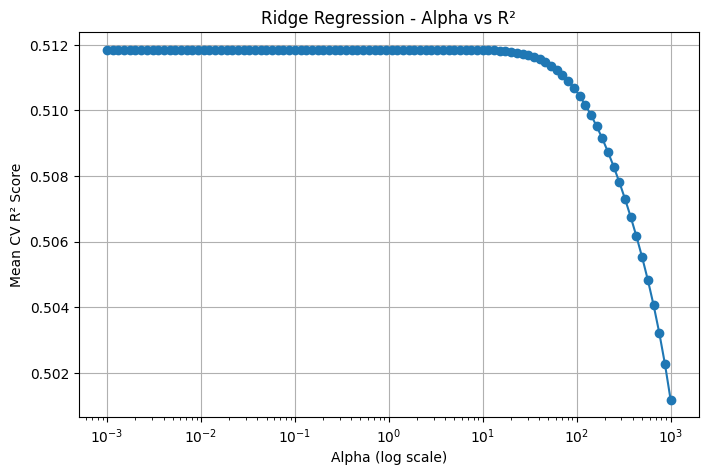

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

results = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(8,5))
plt.semilogx(results["param_regressor__alpha"], results["mean_test_score"], marker="o")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Mean CV R² Score")
plt.title("Ridge Regression - Alpha vs R²")
plt.grid(True)
plt.show()